Logs   
- [2026/03/17]    
  Testing matplotlib

- [2026/03/19]    
  We try to mix with pyplot for interactive plot using slider, but
  the result is very slow.  
  In the end, we use different axes to show the transition

In [ ]:
%load_ext autoreload
%autoreload 2

In [17]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import program.luminance as luminance
import program.color as color

from program.picture import Picture
from PIL import Image
from tqdm import tqdm

In [2]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16, 
  'grid.alpha': 0.25})

In [3]:
mpl.__version__

'3.7.3'

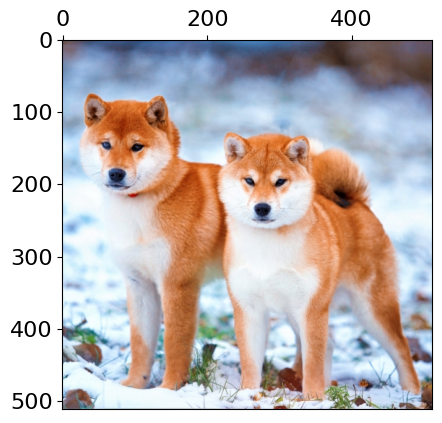

In [4]:
# img_rgb = np.array([
#   [[255,   0,   0],
#    [  0, 255,   0],
#    [  0,   0, 255]],

#   [[  0, 255,   0],
#    [  0,   0, 255],
#    [255,   0,   0]]
# ], dtype=np.uint8)


_DEFAULT_WIDTH = 512
_DEFAULT_HEIGHT = 512

image_path = "./data/japan-shiba-inu-512px.jpg"
# image_path = "./data/mandrill.jpg"
image = Image.open(image_path)
img_rgb = np.array(image)


fig, ax = plt.subplots()

imshow_handler = ax.imshow(img_rgb)

ax.set_aspect("equal")
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

plt.show(fig)

Get the size of the image

In [5]:
fig.get_axes()[0].get_children()[0].get_size()

(512, 512)

Get the pixel color at specific coordinate

In [6]:
a = fig.get_axes()[0].get_children()[0].get_array()
row_color = a[0, 3].data
print(row_color)

def get_color(c1, c2, c3):
  print(c1, c2, c3)

get_color(*row_color)

[98 77 72]
98 77 72


Set the pixel color at specific point

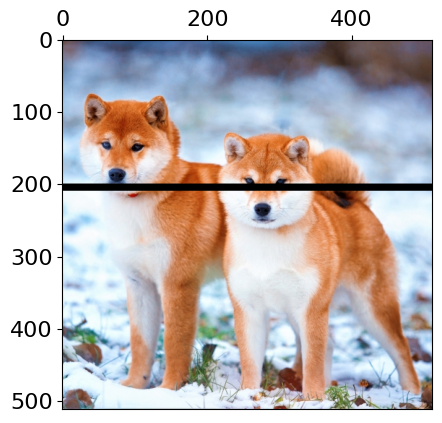

In [7]:
im_data = fig.get_axes()[0].get_children()[0].get_array()
im_data[200:210, :, :] = [0, 0, 0]

fig

test `Picture`

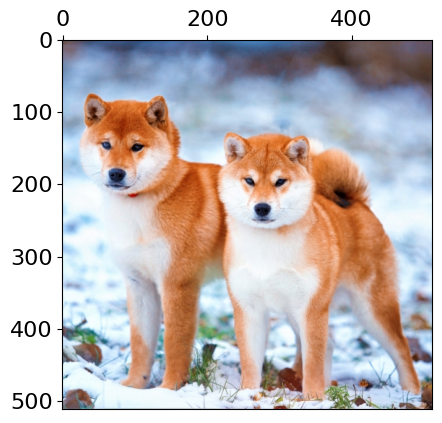

In [8]:
# picture = Picture()
picture = Picture("./data/japan-shiba-inu-512px.jpg")
# picture = Picture("./data/mandrill.jpg")
picture.draw()
plt.show(picture._fig)

In [9]:
picture._surface.shape

(512, 512, 3)

Test grayscale

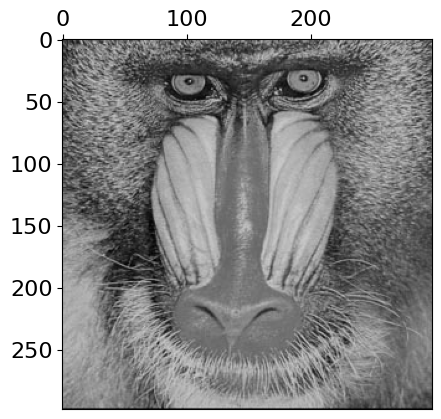

In [10]:
pic = Picture("./data/mandrill.jpg")

# data_color = pic._surface[0, 0, :]
# color.Color(*data_color)
for col in range(pic.width()):
  for row in range(pic.height()):
    pixel = pic.get(col, row)
    # print(pixel, end=" ")
    gray = luminance.to_gray(pixel)
    # print(gray, end=" ")
    pic.set(col, row, gray)
  # print()

pic.draw()

plt.show(pic._fig)

Test image scaling

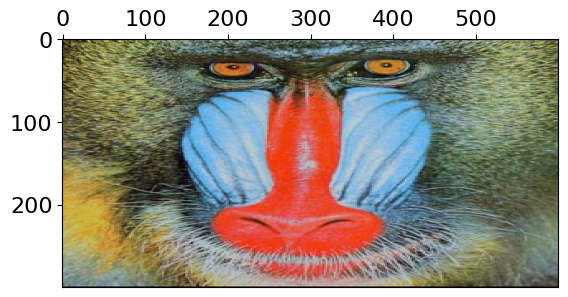

In [11]:
source = Picture("./data/mandrill.jpg")
w_t = 600
h_t = 300

target = Picture(w_t, h_t)
# print(target.width(), target.height())
# print(target._surface[3, 3, :])

for col_t in range(w_t):
  for row_t in range(h_t):
    col_s = col_t * source.width() // w_t
    row_s = row_t * source.height() // h_t
    # print(col_t, row_t, col_s, row_s)
    # print(source.get(col_s, row_s), end=" ")
    target.set(col_t, row_t, source.get(col_s, row_s))
  # print()

# # source._surface[0, 0, :]
# # target._surface[3, 3, :]

target.draw()
plt.show(target._fig)

Fade effect with animation in matplotlib

In [12]:
def blend(c1, c2, alpha):
  r = (1 - alpha) * c1.get_red()   + alpha*c2.get_red()
  g = (1 - alpha) * c1.get_green() + alpha*c2.get_green()
  b = (1 - alpha) * c1.get_blue()  + alpha*c2.get_blue()
  return color.Color(int(r), int(g), int(b))

In [ ]:
source = Picture("./data/mandrill.jpg")
target = Picture("./data/darwin.jpg")
n = 9

width = source.width()
height = source.height()

pic = Picture(width, height)

history_img_src = np.zeros((n+1, *pic._surface.shape), dtype=np.uint8)

t_col_row = [[t, col, row] for t in range(n+1) 
              for col in range(width)
                for row in range(height)]
# -- computational time 18 secs
# for t in range(n+1):
#   for col in range(width):
#     for row in range(height):
for t, col, row in tqdm(t_col_row):
  c_0 = source.get(col, row)
  c_n = target.get(col, row)
  alpha = 1.0 * t / n
  data_color = blend(c_0, c_n, alpha)
  history_img_src[t, row, col, :] = [
    data_color.get_red(), data_color.get_green(), data_color.get_blue()]

history_img_src.shape

100%|██████████| 888040/888040 [00:17<00:00, 50451.84it/s]


(10, 298, 298, 3)

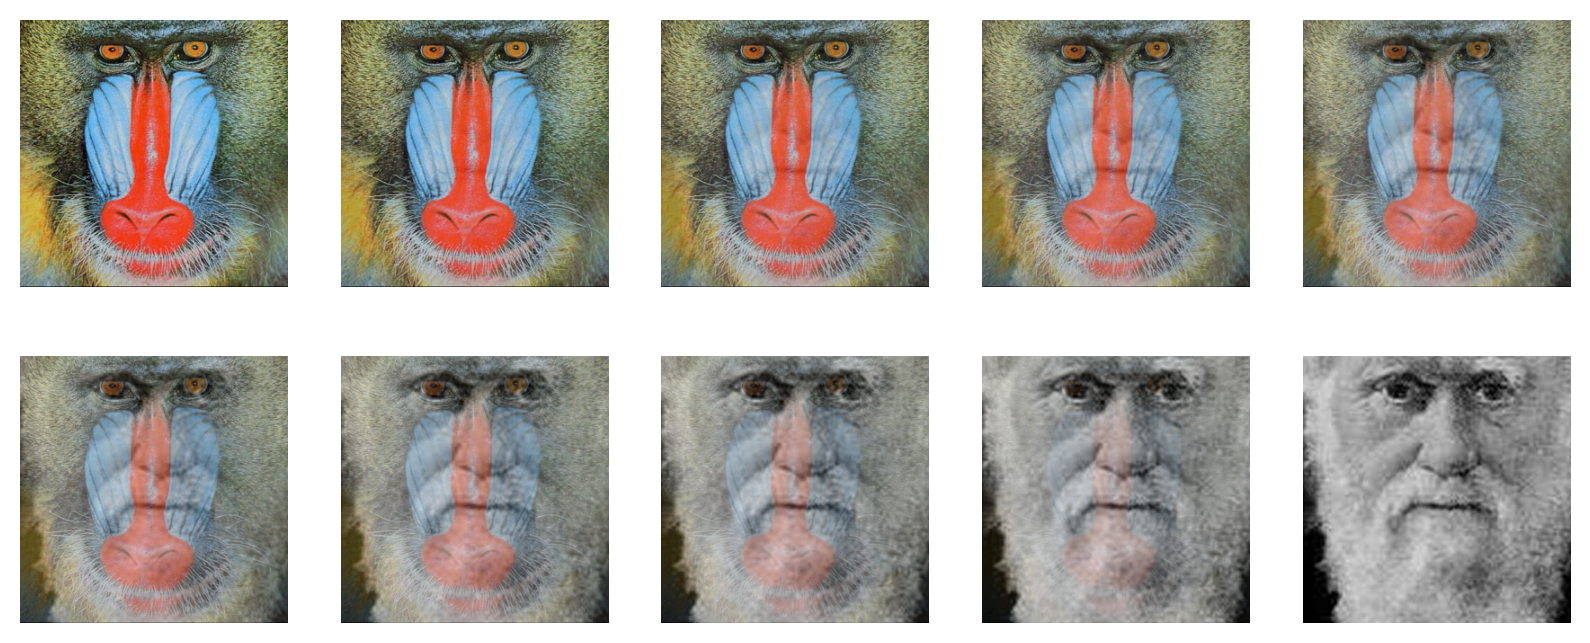

In [25]:
nrows = (n+1)//5
nrows += 1 if (n+1) % 5 != 0 else 0
fig, axes = plt.subplots(nrows=nrows, ncols=5, 
  figsize=(2*5, 2*nrows), sharey=True, dpi=200)
axes = axes.flatten()

for idx, img in enumerate(history_img_src):
  axes[idx].imshow(img)
  axes[idx].set_aspect("equal")
  axes[idx].axis("off")


plt.show(fig)

Get data from `ax.plot`

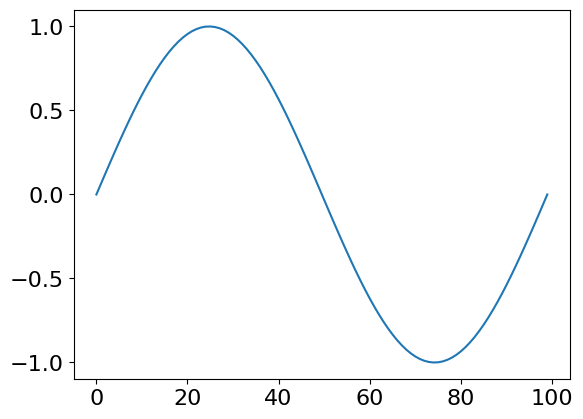

In [15]:
fig, ax = plt.subplots()

line_handler = ax.plot(np.sin(np.linspace(0, 2*np.pi, 100)))

plt.show(fig)

In [16]:
line_handler[0].get_xdata()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
       52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
       65., 66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77.,
       78., 79., 80., 81., 82., 83., 84., 85., 86., 87., 88., 89., 90.,
       91., 92., 93., 94., 95., 96., 97., 98., 99.])